In [1]:
import pandas as pd
from matplotlib.pyplot import *
from scipy import stats
import seaborn as sns

In [2]:
NARROW = 'narrow'
WIDE = 'wide'
CONDITIONS = [NARROW, WIDE]
#COLORS_COND = {NARROW:'C0', WIDE:'C1'}
COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#009E73'; FOURTH_COLOR = 'C4'
M_NARROW = 17.5
M_WIDE = 25.
SD_NARROW = 15./np.sqrt(12)
SD_WIDE   = 30./np.sqrt(12)
W_NARROW = 15.
W_WIDE   = 30.
HW_NARROW = W_NARROW/2
HW_WIDE   = W_WIDE/2

In [3]:
summary = pd.read_csv('stan/outputs/summaries/results_20250909180225.csv', index_col=0)
#summary = pd.read_csv('stan/outputs/summaries_30/results_20250804212421.csv', index_col=0) # prior on m_0 -> 30
#summary = pd.read_csv('stan/outputs/summaries_30/results_20250804214456.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10
summary

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-27492.300000,1.443070,64.707900,64.863700,-27599.300000,-27492.700000,-27386.900000,2010.54,3651.61,1.00348
z_m_0_15[1],0.114610,0.000566,0.021739,0.021247,0.078855,0.114435,0.151094,1480.90,2538.84,1.00544
z_m_0_15[2],0.099510,0.000547,0.022211,0.022235,0.063319,0.099588,0.135871,1653.63,3347.16,1.00280
z_m_0_15[3],0.116600,0.000439,0.022596,0.022414,0.079168,0.116657,0.153351,2666.43,4364.59,1.00258
z_m_0_15[4],0.101373,0.000458,0.022635,0.022545,0.063642,0.101505,0.138453,2448.83,4141.75,1.00395
...,...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.510532,0.001216,0.153398,0.154659,0.255985,0.510545,0.762470,16217.20,7281.18,1.00044
delta_avg_log_var_s_1322[36],0.620238,0.001170,0.152782,0.152259,0.368349,0.619860,0.874401,17369.80,7457.56,1.00030
delta_avg_log_var_s_1322[37],0.727767,0.001210,0.156056,0.154791,0.465421,0.728736,0.985814,16875.30,7503.76,1.00082
delta_avg_log_var_s_1322[38],0.490295,0.001218,0.158946,0.159789,0.229985,0.491158,0.751249,17153.40,7003.40,1.00109


In [4]:
zs = []
for x in summary.index:
    ys = x.split('[')
    if len(ys) == 1:
        zs.append(ys[0])
    else:
        ts = ys[1].split(',')
        if len(ts) == 1:
            zs.append(ys[0] + '[i]')
        else:
            zs.append(ys[0] + '[i,j]')
zs = set(zs)
zs

{'avg_inv_sigma_0_15',
 'avg_inv_sigma_0_30',
 'avg_inv_sigma_0_30_narrowrange',
 'avg_inv_sigma_s_15[i]',
 'avg_inv_sigma_s_15_1124[i]',
 'avg_inv_sigma_s_15_1223[i]',
 'avg_inv_sigma_s_15_1322[i]',
 'avg_inv_sigma_s_30[i]',
 'avg_inv_sigma_s_30_1124[i]',
 'avg_inv_sigma_s_30_1139[i]',
 'avg_inv_sigma_s_30_1223[i]',
 'avg_inv_sigma_s_30_1238[i]',
 'avg_inv_sigma_s_30_1322[i]',
 'avg_inv_sigma_s_30_1337[i]',
 'avg_inv_sigma_s_30_narrowrange[i]',
 'avg_log_var_0_15',
 'avg_log_var_0_30',
 'avg_log_var_0_30_narrowrange',
 'avg_log_var_s_15[i]',
 'avg_log_var_s_15_1124[i]',
 'avg_log_var_s_15_1223[i]',
 'avg_log_var_s_15_1322[i]',
 'avg_log_var_s_30[i]',
 'avg_log_var_s_30_1124[i]',
 'avg_log_var_s_30_1139[i]',
 'avg_log_var_s_30_1223[i]',
 'avg_log_var_s_30_1238[i]',
 'avg_log_var_s_30_1322[i]',
 'avg_log_var_s_30_1337[i]',
 'avg_log_var_s_30_narrowrange[i]',
 'avg_sigma_0_15',
 'avg_sigma_0_30',
 'avg_sigma_0_30_narrowrange',
 'avg_sigma_s_15[i]',
 'avg_sigma_s_15_1124[i]',
 'avg_sigma_

In [5]:
summary.loc[['sqrt_mse_15[10]', 'log_var_0_15[1]', 'sigma_0_15[10]', 'var_0_15[10]']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sqrt_mse_15[10],2.074140,0.001282,0.102709,0.102537,1.911470,2.071310,2.246730,6463.19,6823.61,1.00092
log_var_0_15[1],0.661072,0.001296,0.100296,0.099412,0.495531,0.661053,0.826779,6004.15,7413.92,1.00060
sigma_0_15[10],2.059560,0.001260,0.101329,0.101951,1.898980,2.057110,2.232170,6491.17,6901.94,1.00095
var_0_15[10],4.252050,0.005212,0.419184,0.418012,3.606130,4.231710,4.982600,6491.21,6901.94,1.00095


In [6]:
summary.loc[['tau', 'nu']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
tau,1.305490,0.000737,0.038011,0.038436,1.243710,1.305540,1.36748,2675.15,4833.50,1.00291
nu,0.228636,0.000141,0.008575,0.008415,0.214627,0.228542,0.24293,3754.86,6371.63,1.00219


In [7]:
( summary.R_hat > 1.01 ).mean()

0.0

In [8]:
summary[summary.R_hat>1.01]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat


In [9]:
summary.loc[[f'sigma_0_15[{i}]' for i in range(1,17)] ] #
#summary.loc[['sigma_0_15', 'sigma_0_30'] ] #

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma_0_15[1],1.39346,0.000905,0.069937,0.069030,1.28116,1.39170,1.51194,6004.07,7413.92,1.00060
sigma_0_15[2],1.70083,0.001068,0.084543,0.084427,1.56582,1.69863,1.84444,6356.49,7131.05,1.00059
sigma_0_15[3],2.02809,0.001302,0.099053,0.098267,1.86765,2.02557,2.19479,5823.32,7713.58,1.00037
sigma_0_15[4],1.93368,0.001253,0.095037,0.095161,1.78448,1.93105,2.09543,5829.21,7277.60,1.00178
sigma_0_15[5],1.96094,0.001273,0.096915,0.097266,1.80722,1.95723,2.12628,5897.40,7786.45,1.00022
sigma_0_15[6],2.08434,0.001241,0.099882,0.099431,1.92526,2.08265,2.25413,6490.86,7306.15,1.00068
sigma_0_15[7],2.04328,0.001265,0.097873,0.097058,1.88514,2.04046,2.20926,6027.06,7191.73,1.00086
sigma_0_15[8],2.00897,0.001284,0.098144,0.098363,1.85412,2.00610,2.17448,5907.99,7193.00,1.00175
sigma_0_15[9],2.03987,0.001315,0.100366,0.099616,1.87802,2.03852,2.20776,5866.68,7015.77,1.00022
sigma_0_15[10],2.05956,0.001260,0.101329,0.101951,1.89898,2.05711,2.23217,6491.17,6901.94,1.00095


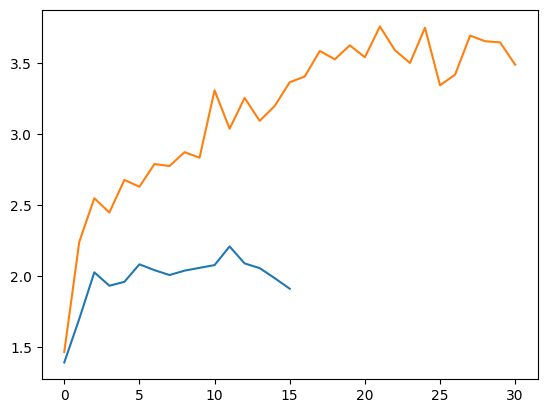

In [10]:
plot( summary.loc[[f'sigma_0_15[{i}]' for i in range(1,16+1)] ].Mean.values )
plot( summary.loc[[f'sigma_0_30[{i}]' for i in range(1,31+1)] ].Mean.values )

In [11]:
summary.loc[[f'sigma_s_15[{sid},{i}]' for i in range(1,17) for sid in range(1,40)] ]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
"sigma_s_15[1,1]",2.06576,0.002166,0.258260,0.252887,1.688390,2.04290,2.52635,16191.5,7042.17,1.00059
"sigma_s_15[2,1]",2.40325,0.002387,0.304252,0.294378,1.955020,2.37704,2.93616,18654.8,7339.12,1.00196
"sigma_s_15[3,1]",1.84445,0.002013,0.259327,0.246238,1.471460,1.81902,2.31088,19017.4,7824.72,1.00077
"sigma_s_15[4,1]",2.59877,0.002608,0.329733,0.319849,2.115270,2.56864,3.19376,18011.7,7289.60,1.00165
"sigma_s_15[5,1]",1.12932,0.001189,0.153931,0.145399,0.901916,1.11460,1.39988,19151.5,6836.70,1.00159
...,...,...,...,...,...,...,...,...,...,...
"sigma_s_15[35,16]",1.85459,0.002100,0.265821,0.257327,1.459960,1.83118,2.32505,18171.4,7831.59,1.00069
"sigma_s_15[36,16]",1.62803,0.002274,0.270587,0.262672,1.241220,1.60000,2.11142,16405.7,7473.55,1.00099
"sigma_s_15[37,16]",1.73988,0.002151,0.277312,0.263903,1.332860,1.71334,2.23784,18571.7,7661.53,1.00117
"sigma_s_15[38,16]",1.85082,0.002397,0.307526,0.298492,1.409200,1.81886,2.40407,18396.3,7631.44,1.00031


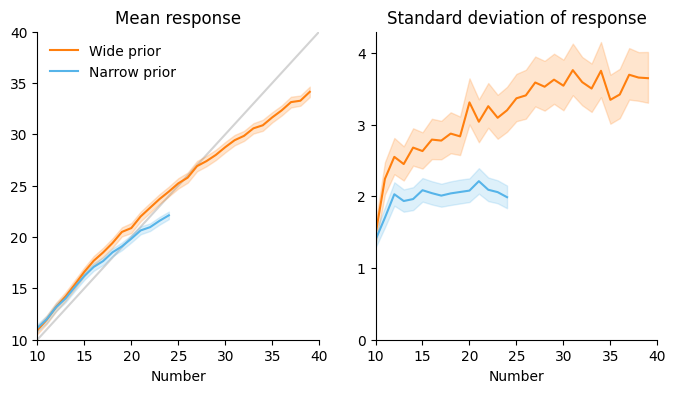

In [12]:
with_mse = False
fig, axs = subplots(ncols=2+with_mse, nrows=1, figsize=(4*(2+with_mse),4))

def plot_subjects_stan(ax_m, ax_sigma):
    qties = ['m_0', 'sigma_0', ] # 'log_inv_var_0']
    if with_mse:
        qties.append('sqrt_mse')
    for iq, qty in enumerate(qties):
        ax = {'m_0': ax_m, 'sigma_0': ax_sigma}[qty]
        if ax is None:
            continue
        for cond in reversed(CONDITIONS):
            c = COLORS_COND[cond]
            xs = np.arange(10, 10 + {NARROW: W_NARROW, WIDE: W_WIDE}[cond], 1)
            vs = []; vs_5 = []; vs_95 = []
            delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
            for j in range(1,delta+1):
                r = summary.loc[f'{qty}_{delta}[{j}]']
                vs.append( r['Mean'] )
                vs_5.append( r['5%'] )
                vs_95.append( r['95%'] )
            ax.plot(xs, vs, c=c, alpha=1., label=cond.capitalize() + ' prior')
            ax.fill_between(xs, vs_5, vs_95, color=c, alpha=.2)
    if False:
        ### TESTS ###
            print('mean', end=' ')
            for i in range(nb_bins):
                p_pos = summary.loc[f'bin_avg_m_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = summary.loc[f'bin_avg_m_0[2,{i+1}]']['Mean']+1  #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,0].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nvariance', end=' ')
            for i in range(nb_bins):
                p_pos = summary.loc[f'bin_avg_sigma_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = max(summary.loc[f'bin_avg_sigma_0[2,{i+1}]']['Mean'],summary.loc[f'bin_avg_sigma_0[1,{i+1}]']['Mean']) + [.5,.3][ie]
                #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,1].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nmse', end=' ')
            # computed on server
            p_pos_priors = np.array([0.4113, 1.    , 1.    , 0.1961, 0.    , 0.    ])
            p_pos_stakes = np.array([1.    , 1.    , 1.    , 0.9938, 0.    , 0.    ])
            for i in range(nb_bins):
                # p_pos = summary.loc[f'bin_avg_sqrt_mse_diff_pos[{i+1}]']['Mean'].squeeze()
                p_pos = (p_pos_priors if experiment==PRIORS else p_pos_stakes)[i]
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = min(summary.loc[f'bin_avg_sqrt_mse[2,{i+1}]']['Mean'],summary.loc[f'bin_avg_sqrt_mse[1,{i+1}]']['Mean']) - .5
                if pv<.001:
                    axs[ie,2].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print()

plot_subjects_stan(axs[0], axs[1])
axs = axs.flat
axs[0].legend(loc='upper left')
#axs[0].set_ylabel('Response'); # $\hat x$
#axs[1].set_ylabel('Standard deviation of response');
axs[0].set_title('Mean response')
axs[1].set_title('Standard deviation of response')
if with_mse:
    axs[2].set_ylabel('$\sqrt{MSE} = \sqrt{bias^2 + variance}$');
for ax in axs: #.flatten():
    ax.set_xlim(10,40)
    #ax.set_xticks([30,40,50,60,70,80,90])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axs[1].set_ylim(0,None)
axs[1].set_yticks([0,1,2,3,4])
axs[0].set_ylim(10,40)
axs[0].axline((10,10), slope=1, c='lightgrey', zorder=-100)
# for ax in axs[:,0]:
#     ax.set_ylim(41,80)
#     ax.set_yticks([41,50,60,70,80])
#     ax.axline((60,60), slope=1, c='lightgrey', zorder=-1000)
# for ax in axs[:,1]:
#     ax.set_ylim(1.7,5.)
#     ax.set_yticks([2,3,4,5])
# for ax in axs[:,2]:
#     ax.set_ylim(2,11)
#     ax.set_yticks([2,4,6,8,10])
for ax in axs:
    ax.set_xlabel('Number') # $x$
#axs[1].set_xlim(13,22)
#fig.savefig(apc.todayDirPath() + '/subjects.pdf', bbox_inches='tight', transparent=False)

In [13]:
np.arange(10, 10+W_NARROW+1)

array([10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22.,
       23., 24., 25.])

In [14]:
def norm(x, mu, w):
    return np.exp(-.5*((x-mu)/w)**2)

def prf(x, mu, w):
    return norm( np.log(x), np.log(mu), w )


In [15]:
def plot_prior(ax, x0, x1, v, c, zorder=None, ylabel='Probability'):
    ax.plot([x0,x1], [v, v], c=c, zorder=zorder)
    ax.plot([x0,x0], [0, v], c=c, ls=':', zorder=zorder)
    ax.plot([x1,x1], [0, v], c=c, ls=':', zorder=zorder)
    if ylabel:
        ax.set_ylabel(ylabel)

In [16]:
from matplotlib.patches import ConnectionPatch

7.5 10.0 12.5 15.0 17.5 20.0 22.5 25.0 

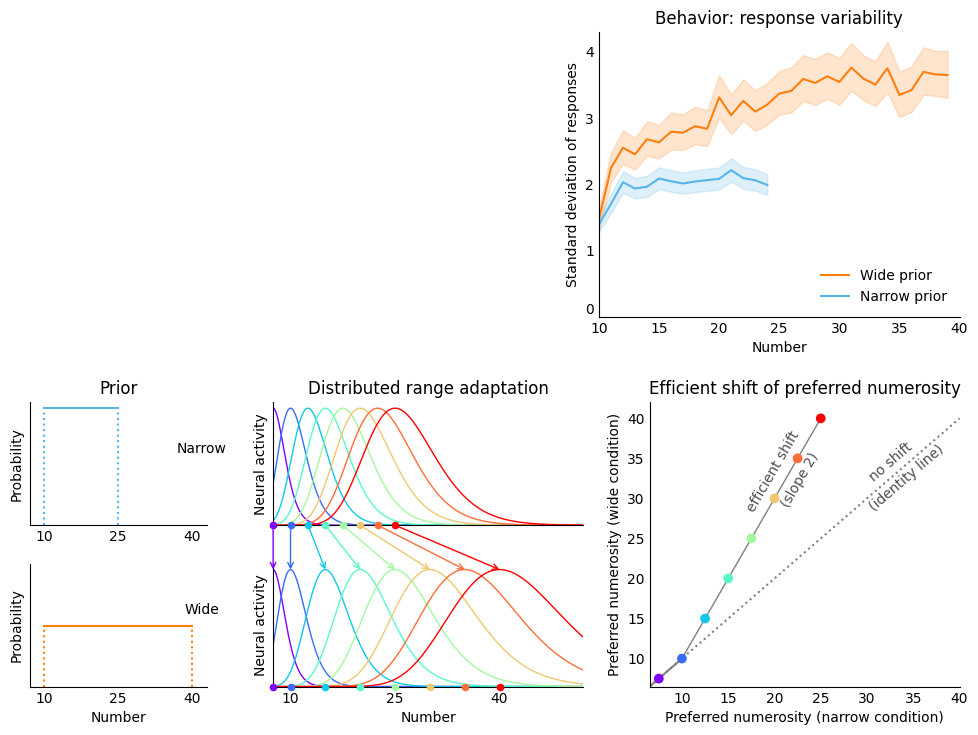

In [17]:
fig, axs = subplots(nrows=3, ncols=3, figsize=(12,8.5), width_ratios=[8,14,14], height_ratios=[2.7,1,1])

gs = axs[0, 0].get_gridspec()
for ax in axs[1:, 2]:
    ax.remove()
axbig = fig.add_subplot(gs[1:, 2])
axs[0,0].remove()
axs[0,1].remove()

axPriorN = axs[1,0]
axPriorW = axs[2,0]
axRF_N = axs[1,1]
axRF_W = axs[2,1]

#axStdDev = axs[0,2]
axs[0,2].remove()
gs_top = GridSpec(nrows=2, ncols=10, hspace=.3)
axStdDev = fig.add_subplot(gs_top[0, 6:])
#axStdDev = fig.add_subplot( 2, 2, 2 )

#### Std Dev subjects
plot_subjects_stan(ax_m=None, ax_sigma=axStdDev)
#axs[0].legend(loc='upper left')
#axs[0].set_title('Mean response')
axStdDev.set_title('Behavior: response variability')
axStdDev.set_xlim(10,40)
axStdDev.set_ylim(0,None)
axStdDev.set_yticks([0,1,2,3,4])
axStdDev.set_xlabel('Number') # $x$
axStdDev.set_ylabel('Standard deviation of responses') # $\hat x$
axStdDev.legend(loc='lower right', )
axStdDev.get_yticklabels()[0].set_verticalalignment('bottom')
#####

sigma = .2
xx = np.linspace(5, 56, 500)
no_change = False
pref_nums = np.arange(7.5,26,2.5) #np.arange(7,26,1) #np.array([7, 9, 10, 11, 13, 15, 17, 19]) #np.arange(5, 26, 5)
num_tcs = len(pref_nums)
cmap = cm.rainbow

### priors
plot_prior(axPriorN, 10, 25, 1./16, c=COLORS_COND[NARROW])
plot_prior(axPriorW, 10, 40, 1./31, c=COLORS_COND[WIDE])
axPriorW.set_ylim( *axPriorN.get_ylim() )
axPriorW.set_xlabel('Number')
axPriorN.set_title('Prior')
axPriorN.text(42,1.2/31,'Narrow', ma='center', ha='center')
axPriorW.text(42,1.2/31,'Wide', ma='center', ha='center')
for ax in axs[1:,0]: ax.set_xlim(7,43)

### receptive fields
pref_nums_w = []
for ii,mode in enumerate( pref_nums ):
    #print(mode)
    c = cmap( (mode-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) ) #cmap(ii/num_tcs)
    axRF_N.plot(xx, prf(xx, mode, sigma), lw=1, c=c)
    axRF_N.scatter(x=mode, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[0,1], 10, 25, .5, c=COLORS_COND[NARROW], ylabel=None, zorder=-1000)
    mode_w = mode if no_change or mode <= 10 else ( 10 + 2*(mode-10) )
    pref_nums_w.append(mode_w)
    sigma_w = sigma #if no_change else np.sqrt(2)*sigma
    axRF_W.plot(xx, prf(xx, mode_w, sigma_w), lw=1, c=c)
    axRF_W.scatter(x=mode_w, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[1,1], 10, 40, .25, c=COLORS_COND[WIDE], ylabel=None, zorder=-1000)
for ax in axs[1:,:2].flatten():
    ax.set_yticks([])
    ax.set_ylim(0,None); #ax.set_xlim(10,40)
    #ax.set_xticks([10,15,20,25,30,35,40])
    ax.set_xticks([10,25,40])
axRF_N.set_xticklabels([])
#axRF_N.set_title('Receptive fields') #('Tuning curves')
axRF_N.set_title('Distributed range adaptation') #('Tuning curves')
axRF_N.set_ylabel('Neural activity')
axRF_W.set_ylabel('Neural activity')
axRF_W.set_xlabel('Number')
for ax in axs[1:,1]: ax.set_xlim(pref_nums[0],52)

#for pref_n in [10, 15, 20, 25]:
#for pref_n in pref_nums[1:]:
for pref_n in pref_nums[:]:
    print(pref_n, end=' ')
    pref_w = pref_n if no_change or pref_n <= 10 else ( 10 + 2*(pref_n-10) )
    c = cmap( (pref_n-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) )
    con = ConnectionPatch(xyA=(pref_n, 0), xyB=(pref_w, prf(pref_w,pref_w,sigma)), coordsA='data', coordsB='data',
            axesA=axRF_N, axesB=axRF_W, color=c, arrowstyle='->', linewidth=1, zorder=100)
    axRF_W.add_artist(con)

axbig.scatter(pref_nums, pref_nums_w, c=cmap( (pref_nums-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) ), zorder=1000, clip_on=False)
axbig.plot([5,10], [5,10], c='grey')
axbig.axline([10,10], slope=1, ls=':', c='grey')
axbig.set_xlim(pref_nums[0]-1, 40) # 28)
axbig.plot([10,25],[10,40], c='grey', lw=1)
#axbig.text(29.25, 29.8, 'no adaptation\n(identity line)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
axbig.text(30, 30+2.15, 'no shift', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
axbig.text(30, 28.4, '(identity line)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
# axbig.annotate('efficient adaptation\n(slope = 2)', xy=(20,30), xytext=(15, 35), c=(.2,)*3, ma='center', ha='center',
#                arrowprops=dict(arrowstyle="->", connectionstyle="arc", color='grey'), ) # rotation=0, 
axbig.text(16.8, 28.4, 'efficient shift', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(2)), transform_rotates_text=True)
axbig.text(20.5, 29, '(slope 2)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(2)), transform_rotates_text=True)
axbig.set_ylim(pref_nums[0]-1, 42)
axbig.set_xlabel('Preferred numerosity (narrow condition)')
axbig.set_ylabel('Preferred numerosity (wide condition)')
axbig.set_title('Efficient shift of preferred numerosity')
axbig.set_xticks([10,15,20,25,30,35,40])
fig.subplots_adjust(wspace=.25)

sns.despine(fig=fig)
for ax in fig.axes:
    ax.tick_params(axis='both', length=0)

#fig.savefig('figures/subjs_stddev_priors_effcod.pdf', bbox_inches='tight')

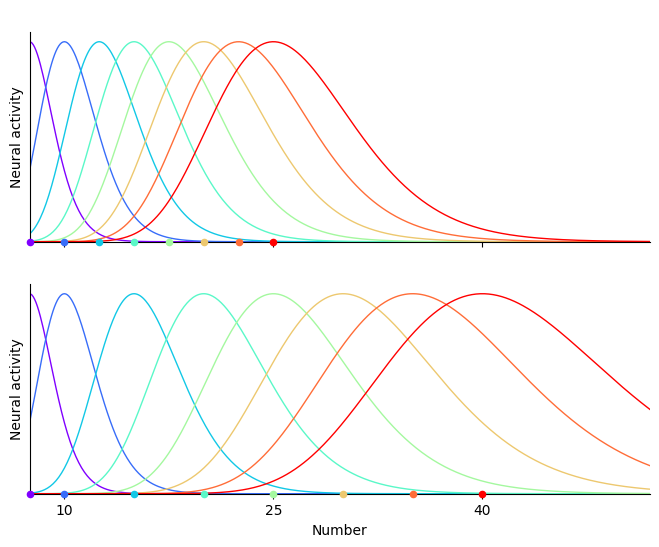

In [18]:
### receptive fields

fig, axs = subplots(nrows=2, figsize=(8,6))
axRF_N, axRF_W = axs

pref_nums_w = []
for ii,mode in enumerate( pref_nums ):
    #print(mode)
    c = cmap( (mode-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) ) #cmap(ii/num_tcs)
    axRF_N.plot(xx, prf(xx, mode, sigma), lw=1, c=c)
    axRF_N.scatter(x=mode, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[0,1], 10, 25, .5, c=COLORS_COND[NARROW], ylabel=None, zorder=-1000)
    mode_w = mode if no_change or mode <= 10 else ( 10 + 2*(mode-10) )
    pref_nums_w.append(mode_w)
    sigma_w = sigma #if no_change else np.sqrt(2)*sigma
    axRF_W.plot(xx, prf(xx, mode_w, sigma_w), lw=1, c=c)
    axRF_W.scatter(x=mode_w, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[1,1], 10, 40, .25, c=COLORS_COND[WIDE], ylabel=None, zorder=-1000)
for ax in axs:
    ax.set_yticks([])
    ax.set_ylim(0,None); #ax.set_xlim(10,40)
    #ax.set_xticks([10,15,20,25,30,35,40])
    ax.set_xticks([10,25,40])
axRF_N.set_xticklabels([])
#axRF_N.set_title('Receptive fields') #('Tuning curves')
axRF_N.set_title(' ') #Distributed range adaptation') #('Tuning curves')
axRF_N.set_ylabel('Neural activity')
axRF_W.set_ylabel('Neural activity')
axRF_W.set_xlabel('Number')
for ax in axs: ax.set_xlim(pref_nums[0],52)
sns.despine(fig=fig)

fig.savefig('figures/receptive_fields.pdf', bbox_inches='tight', transparent=False)

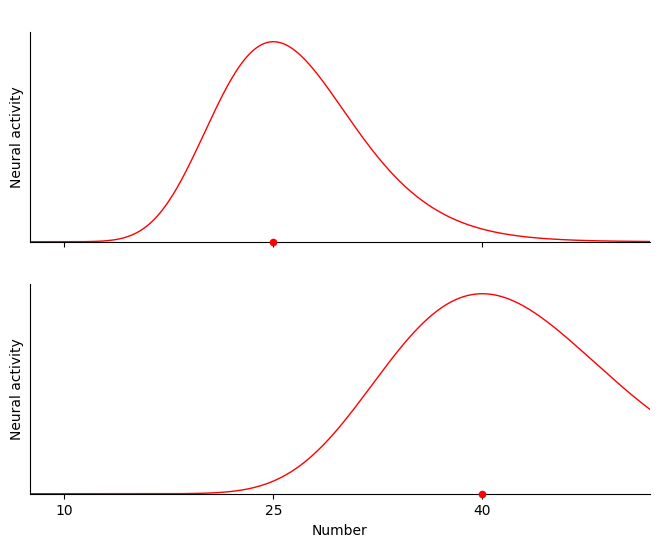

In [19]:
### receptive fields

fig, axs = subplots(nrows=2, figsize=(8,6))
axRF_N, axRF_W = axs

pref_nums_w = []
for ii,mode in enumerate( [25,] ):
    #print(mode)
    c = cmap( (mode-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) ) #cmap(ii/num_tcs)
    axRF_N.plot(xx, prf(xx, mode, sigma), lw=1, c=c)
    axRF_N.scatter(x=mode, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[0,1], 10, 25, .5, c=COLORS_COND[NARROW], ylabel=None, zorder=-1000)
    mode_w = mode if no_change or mode <= 10 else ( 10 + 2*(mode-10) )
    pref_nums_w.append(mode_w)
    sigma_w = sigma #if no_change else np.sqrt(2)*sigma
    axRF_W.plot(xx, prf(xx, mode_w, sigma_w), lw=1, c=c)
    axRF_W.scatter(x=mode_w, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[1,1], 10, 40, .25, c=COLORS_COND[WIDE], ylabel=None, zorder=-1000)
for ax in axs:
    ax.set_yticks([])
    ax.set_ylim(0,None); #ax.set_xlim(10,40)
    #ax.set_xticks([10,15,20,25,30,35,40])
    ax.set_xticks([10,25,40])
axRF_N.set_xticklabels([])
#axRF_N.set_title('Receptive fields') #('Tuning curves')
axRF_N.set_title(' ') #Distributed range adaptation') #('Tuning curves')
axRF_N.set_ylabel('Neural activity')
axRF_W.set_ylabel('Neural activity')
axRF_W.set_xlabel('Number')
for ax in axs: ax.set_xlim(pref_nums[0],52)
sns.despine(fig=fig)

fig.savefig('figures/one_receptive_field.pdf', bbox_inches='tight', transparent=False)

# Estimates, bias

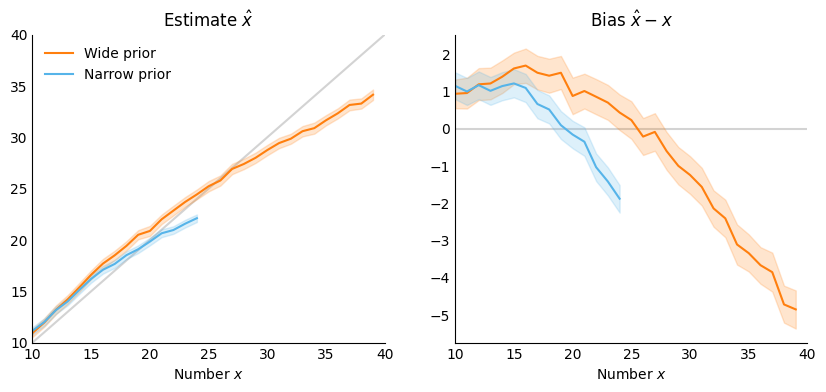

In [20]:
fig, axs = subplots(ncols=2, nrows=1, figsize=(10,4))

#qties = ['m_0', 'sigma_0', ] 
for cond in reversed(CONDITIONS):
    c = COLORS_COND[cond]
    xs = np.arange(10, 10 + {NARROW: W_NARROW, WIDE: W_WIDE}[cond], 1)
    vs = []; vs_5 = []; vs_95 = []
    delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
    for j in range(1,delta+1):
        r = summary.loc[f'm_0_{delta}[{j}]']
        vs.append( r['Mean'] )
        vs_5.append( r['5%'] )
        vs_95.append( r['95%'] )
    axs[0].plot(xs, vs, c=c, alpha=1., label=cond.capitalize() + ' prior')
    axs[0].fill_between(xs, vs_5, vs_95, color=c, alpha=.2)
    #
    axs[1].plot(xs, vs-xs, c=c, alpha=1., label=cond.capitalize() + ' prior')
    axs[1].fill_between(xs, vs_5-xs, vs_95-xs, color=c, alpha=.2)

axs = axs.flat
axs[0].legend(loc='upper left')
axs[0].set_title('Estimate $\hat x$')
axs[1].set_title('Bias $\hat x - x$')
for ax in axs: #.flatten():
    ax.set_xlim(10,40)
    ax.tick_params(axis='both', length=0)
axs[0].set_ylim(10,40)
axs[0].axline((10,10), slope=1, c='lightgrey', zorder=-100)
axs[1].axhline(0, c='lightgrey', zorder=-100)
for ax in axs:
    ax.set_xlabel('Number $x$') # $x$
sns.despine(fig=fig)
fig.savefig('figures/subjs_estimates.pdf', bbox_inches='tight', transparent=False)

In [30]:
summary.loc[[f'm_s_15[{i},1]' for i in range(1,40)] ]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
"m_s_15[1,1]",11.6271,0.003442,0.448643,0.446040,10.88690,11.6270,12.3624,17562.2,6749.31,1.00167
"m_s_15[2,1]",12.7403,0.004489,0.613389,0.618615,11.73760,12.7471,13.7459,18964.9,7524.46,1.00189
"m_s_15[3,1]",11.6433,0.003389,0.463329,0.455603,10.88960,11.6415,12.3957,19241.3,6992.40,1.00153
"m_s_15[4,1]",12.2268,0.004774,0.651874,0.634405,11.13330,12.2317,13.2946,19036.1,7013.03,1.00164
"m_s_15[5,1]",10.2921,0.001694,0.218804,0.209566,9.93582,10.2897,10.6595,17036.9,7144.12,1.00115
"m_s_15[6,1]",10.2788,0.001826,0.230085,0.223724,9.91166,10.2751,10.6597,16372.4,7317.51,0.99989
"m_s_15[7,1]",10.5825,0.001913,0.250478,0.241145,10.18060,10.5793,11.0028,17605.6,7267.59,1.00058
"m_s_15[8,1]",10.7484,0.003967,0.515954,0.507272,9.91206,10.7400,11.6019,17611.8,7055.51,1.00230
"m_s_15[9,1]",11.9034,0.003592,0.439147,0.420169,11.16440,11.9097,12.6105,15591.2,6537.60,1.00126
"m_s_15[10,1]",10.6978,0.002550,0.340049,0.326469,10.13180,10.6976,11.2619,18404.6,6898.66,1.00151


In [45]:
real_sids = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]

# individual

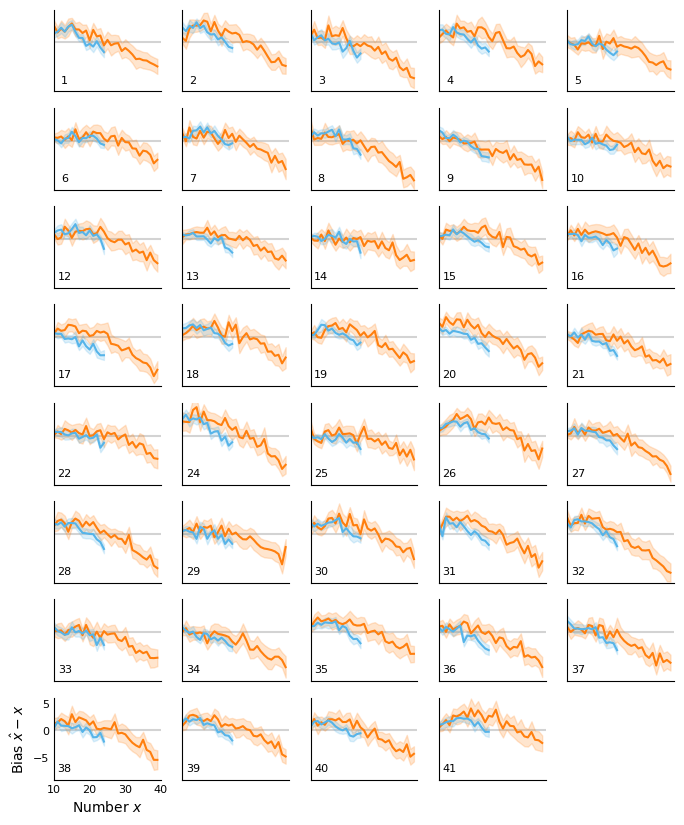

In [74]:
fig, axs = subplots(ncols=5, nrows=8, figsize=(8,10))

for sid in range(1,40):
    ax = axs.flat[sid-1]
    for cond in reversed(CONDITIONS):
        c = COLORS_COND[cond]
        xs = np.arange(10, 10 + {NARROW: W_NARROW, WIDE: W_WIDE}[cond], 1)
        vs = []; vs_5 = []; vs_95 = []
        delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
        for j in range(1,delta+1):
            r = summary.loc[f'm_s_{delta}[{sid},{j}]']
            vs.append( r['Mean'] )
            vs_5.append( r['5%'] )
            vs_95.append( r['95%'] )
        ax.plot(xs, vs-xs, c=c, alpha=1., label=cond.capitalize() + ' prior')
        ax.fill_between(xs, vs_5-xs, vs_95-xs, color=c, alpha=.2)
    ax.set_title(real_sids[sid-1], fontsize=8, x=0.1, y=0)
    ax.set_xlim(10,40)
    ax.tick_params(axis='both', length=0)
    ax.set_ylim(-9,6)
    #ax.axline((10,10), slope=1, c='lightgrey', zorder=-100)
    ax.axhline(0, c='lightgrey', zorder=-100)
    #ax.set_xlabel('Number $x$') # $x$
    ax.set_xticks([])
    ax.set_yticks([])
axs[7,0].set_xticks([10,20,30,40])
axs[7,0].xaxis.set_tick_params(labelsize=8)
axs[7,0].set_yticks([-5,0,5])
axs[7,0].yaxis.set_tick_params(labelsize=8)
axs[7,0].set_xlabel('Number $x$')
axs[7,0].set_ylabel('Bias $\hat x - x$')
axs[-1,-1].remove()
sns.despine(fig=fig)
fig.savefig('figures/subjs_indiv_estimates.pdf', bbox_inches='tight')

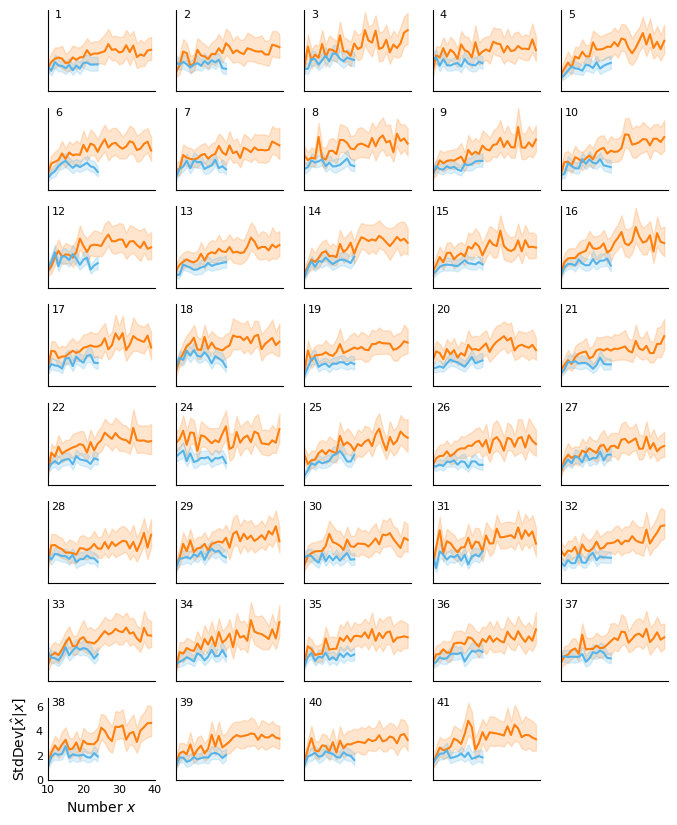

In [75]:
fig, axs = subplots(ncols=5, nrows=8, figsize=(8,10))

for sid in range(1,40):
    ax = axs.flat[sid-1]
    for cond in reversed(CONDITIONS):
        c = COLORS_COND[cond]
        xs = np.arange(10, 10 + {NARROW: W_NARROW, WIDE: W_WIDE}[cond], 1)
        vs = []; vs_5 = []; vs_95 = []
        delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
        for j in range(1,delta+1):
            r = summary.loc[f'sigma_s_{delta}[{sid},{j}]']
            vs.append( r['Mean'] )
            vs_5.append( r['5%'] )
            vs_95.append( r['95%'] )
        ax.plot(xs, vs, c=c, alpha=1., label=cond.capitalize() + ' prior')
        ax.fill_between(xs, vs_5, vs_95, color=c, alpha=.2)
    ax.set_title(real_sids[sid-1], fontsize=8, x=0.1, y=0.8)
    ax.set_xlim(10,40)
    ax.tick_params(axis='both', length=0)
    ax.set_ylim(0,6.7)
    ax.set_xticks([])
    ax.set_yticks([])
axs[7,0].set_xticks([10,20,30,40])
axs[7,0].xaxis.set_tick_params(labelsize=8)
#axs[7,0].get_xticklabels()[0].set_ha('left')
axs[7,0].set_yticks([0,2,4,6])
axs[7,0].yaxis.set_tick_params(labelsize=8)
#axs[7,0].get_yticklabels()[0].set_y(0.5)
axs[-1,-1].remove()
sns.despine(fig=fig)
axs[7,0].set_xlabel('Number $x$')
axs[7,0].set_ylabel('StdDev$[\hat x | x]$')
fig.savefig('figures/subjs_indiv_sd.pdf', bbox_inches='tight')

# fMRI-derived estimates

In [59]:
#summary_fmri = pd.read_csv('stan/outputs/summaries_fmri_30/results_20250804221241.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10
summary_fmri = pd.read_csv('stan/outputs/summaries_fmri_30/results_20250804230132.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10, prior tau, nu
summary_fmri

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-53976.400000,1.150510,48.052000,-54054.500000,-53977.100000,-53896.700000,1744.38,2.7466,1.007210
z_m_0_15[1],0.347750,0.000103,0.013147,0.326184,0.347822,0.369634,16156.90,25.4396,0.999686
z_m_0_15[2],0.295590,0.000112,0.013020,0.273958,0.295619,0.316875,13554.10,21.3415,0.999810
z_m_0_15[3],0.252856,0.000107,0.013107,0.231918,0.252739,0.274820,15115.70,23.8002,0.999593
z_m_0_15[4],0.198327,0.000100,0.012127,0.178266,0.198420,0.218509,14644.50,23.0583,0.999623
...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.304574,0.000285,0.033352,0.249837,0.304637,0.359477,13720.00,21.6026,0.999678
delta_avg_log_var_s_1322[36],0.305053,0.000279,0.033348,0.250431,0.304978,0.360579,14292.00,22.5034,0.999645
delta_avg_log_var_s_1322[37],0.305221,0.000274,0.033189,0.251288,0.305200,0.360276,14657.60,23.0790,0.999489
delta_avg_log_var_s_1322[38],0.304864,0.000284,0.033306,0.250051,0.305037,0.359334,13730.00,21.6184,0.999471


In [60]:
( summary_fmri.R_hat > 1.01 ).mean()

5.600672080649678e-05

In [61]:
summary_fmri[summary_fmri.R_hat>1.01]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,0.441794,0.008213,0.240245,0.052657,0.443699,0.832721,855.66852,1.347282,1.019188


In [ ]:
summary_fmri.loc[['tau', 'nu', 'sigma_0_15[1]', 'sigma_0_15[10]', 'sigma_0_30[1]', 'sigma_0_30[10]']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,0.441794,0.008213,0.240245,0.052657,0.443699,0.832721,855.66852,1.347282,1.019188
nu,0.006775,0.000063,0.005135,0.000492,0.005775,0.016620,6570.43212,10.345394,1.000549
sigma_0_15[1],9.204450,0.002182,0.272549,8.768300,9.197260,9.661690,15601.60000,24.565300,0.999840
sigma_0_15[10],9.302670,0.002277,0.283145,8.850170,9.296870,9.777000,15462.50000,24.346200,0.999658
sigma_0_30[1],10.817800,0.003681,0.468077,10.078300,10.799400,11.619700,16173.70000,25.466100,1.000100
sigma_0_30[10],10.504400,0.003394,0.426018,9.835980,10.488700,11.221000,15751.70000,24.801700,0.999799


In [71]:
summary.loc[['tau', 'nu', 'sigma_0_15[1]', 'sigma_0_15[10]', 'sigma_0_30[1]', 'sigma_0_30[10]']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,1.30472,0.000730,0.037610,1.24341,1.30383,1.36754,2690.12000,4.37988,1.00309
nu,0.22874,0.000140,0.008600,0.21463,0.22877,0.24292,3852.58381,6.27252,1.00241
sigma_0_15[1],1.39327,0.000967,0.070394,1.28122,1.39188,1.51113,5294.46000,8.62009,1.00056
sigma_0_15[10],2.06255,0.001342,0.101933,1.89974,2.05994,2.23650,5770.30000,9.39483,1.00059
sigma_0_30[1],1.47001,0.001180,0.096615,1.31683,1.46669,1.63495,6698.73000,10.90640,1.00054
sigma_0_30[10],2.83089,0.001995,0.168354,2.56815,2.82320,3.12039,7123.87000,11.59860,1.00082


NameError: name 'summary_fmri' is not defined

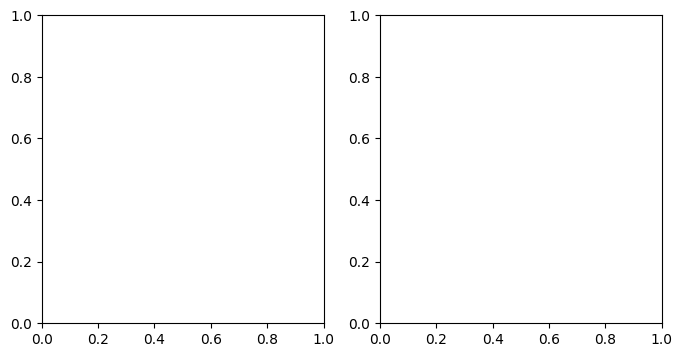

In [73]:
with_mse = False
fig, axs = subplots(ncols=2+with_mse, nrows=1, figsize=(4*(2+with_mse),4))

def plot_fmri_subjects_stan(ax_m, ax_sigma):
    qties = ['m_0', 'sigma_0', ] # 'log_inv_var_0']
    if with_mse:
        qties.append('sqrt_mse')
    for iq, qty in enumerate(qties):
        ax = {'m_0': ax_m, 'sigma_0': ax_sigma}[qty]
        if ax is None:
            continue
        for cond in reversed(CONDITIONS):
            c = COLORS_COND[cond]
            xs = np.arange(10, 10 + {NARROW: W_NARROW, WIDE: W_WIDE}[cond], 1)
            vs = []; vs_5 = []; vs_95 = []
            delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
            for j in range(1,delta+1):
                r = summary_fmri.loc[f'{qty}_{delta}[{j}]']
                vs.append( r['Mean'] )
                vs_5.append( r['5%'] )
                vs_95.append( r['95%'] )
            ax.plot(xs, vs, c=c, alpha=1., label=cond.capitalize())
            ax.fill_between(xs, vs_5, vs_95, color=c, alpha=.2)
    if False:
        ### TESTS ###
            print('mean', end=' ')
            for i in range(nb_bins):
                p_pos = summary_fmri.loc[f'bin_avg_m_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = summary_fmri.loc[f'bin_avg_m_0[2,{i+1}]']['Mean']+1  #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,0].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nvariance', end=' ')
            for i in range(nb_bins):
                p_pos = summary_fmri.loc[f'bin_avg_sigma_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = max(summary_fmri.loc[f'bin_avg_sigma_0[2,{i+1}]']['Mean'],summary_fmri.loc[f'bin_avg_sigma_0[1,{i+1}]']['Mean']) + [.5,.3][ie]
                if pv<.001:
                    axs[ie,1].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nmse', end=' ')
            # computed on server
            p_pos_priors = np.array([0.4113, 1.    , 1.    , 0.1961, 0.    , 0.    ])
            p_pos_stakes = np.array([1.    , 1.    , 1.    , 0.9938, 0.    , 0.    ])
            for i in range(nb_bins):
                p_pos = (p_pos_priors if experiment==PRIORS else p_pos_stakes)[i]
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = min(summary_fmri.loc[f'bin_avg_sqrt_mse[2,{i+1}]']['Mean'],summary_fmri.loc[f'bin_avg_sqrt_mse[1,{i+1}]']['Mean']) - .5
                if pv<.001:
                    axs[ie,2].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print()

plot_fmri_subjects_stan(axs[0], axs[1])
axs = axs.flat
axs[0].legend(loc='upper left')
#axs[0].set_ylabel('Response'); # $\hat x$
#axs[1].set_ylabel('Standard deviation of response');
axs[0].set_title('Mean response')
axs[1].set_title('Standard deviation of response')
if with_mse:
    axs[2].set_ylabel('$\sqrt{MSE} = \sqrt{bias^2 + variance}$');
for ax in axs: #.flatten():
    ax.set_xlim(10,40)
    #ax.set_xticks([30,40,50,60,70,80,90])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axs[1].set_ylim(0,None)
axs[1].set_yticks([0,1,2,3,4])
axs[0].set_ylim(10,40)
axs[0].axline((10,10), slope=1, c='lightgrey', zorder=-100)
# for ax in axs[:,0]:
#     ax.set_ylim(41,80)
#     ax.set_yticks([41,50,60,70,80])
#     ax.axline((60,60), slope=1, c='lightgrey', zorder=-1000)
# for ax in axs[:,1]:
#     ax.set_ylim(1.7,5.)
#     ax.set_yticks([2,3,4,5])
# for ax in axs[:,2]:
#     ax.set_ylim(2,11)
#     ax.set_yticks([2,4,6,8,10])
for ax in axs:
    ax.set_xlabel('Number') # $x$
#axs[1].set_xlim(13,22)
#fig.savefig(apc.todayDirPath() + '/subjects.pdf', bbox_inches='tight', transparent=False)